# Ejercicio 01 · Dataset público y SVM reproducible
**Kendy Báez Santos** · INF-8239 Ciencia de Datos II

## 1. Configuración y Ejecución del Motor Analítico
En esta sección establecemos las rutas dinámicas para garantizar que el código sea reproducible en cualquier entorno. Al invocar la función `ejecutar()`, el *backend* descarga los datos, aplica la partición estratificada (previniendo la fuga de datos), entrena el pipeline (Imputación, PCA, SVM) y calcula las métricas frente a un clasificador de línea base.

In [14]:
from pathlib import Path
import sys
import pandas as pd
import json
from IPython.display import display, Image, Markdown

cwd = Path.cwd().resolve()
if cwd.name == 'notebooks':
    ROOT = cwd.parent
elif cwd.name == 'Ciencia de DatosII':
    ROOT = cwd / 'Unidad I' / 'Ejercicio 01'
else:
    ROOT = cwd

sys.path.insert(0, str(ROOT / 'src'))

from laboratorio_e01 import ejecutar
resultados = ejecutar()
display(resultados)

c:\Users\kebaez\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\kebaez\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\kebaez\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\kebaez\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\

,modelo,particion,accuracy,f1_macro,precision_macro,recall_0,recall_1,roc_auc
0,Baseline,entrenamiento,0.541436,0.351254,0.270718,1.000000,0.000000,0.500000
1,Baseline,validacion,0.540984,0.351064,0.270492,1.000000,0.000000,0.500000
2,Baseline,prueba,0.540984,0.351064,0.270492,1.000000,0.000000,0.500000
3,SVM,entrenamiento,0.839779,0.836403,0.845757,0.908163,0.759036,0.901647
4,SVM,validacion,0.852459,0.849877,0.856667,0.909091,0.785714,0.902056
5,SVM,prueba,0.868852,0.865934,0.877252,0.939394,0.785714,0.933983


## 2. Ficha Comparativa y Selección
Justificación técnica de la elección del dataset *Heart Disease (Cleveland)*, destacando su idoneidad para demostrar técnicas de imputación de nulos y reducción dimensional.

In [38]:
display(Markdown((ROOT / 'reports/seleccion_dataset.md').read_text(encoding='utf-8')))

# Comparación de datasets y solicitud de aprobación

| Criterio | Heart Disease (Cleveland) (propuesto) | Breast Cancer Wisconsin |
|---|---|---|
| Fuente | UCI | UCI |
| Registros / predictores | 303 / 13 | 569 / 30 |
| Problema | Predecir presencia de enfermedad cardíaca | Clasificar tumores como malignos o benignos |
| Licencia | CC BY 4.0 | CC BY 4.0 |
| Faltantes | Sí (representados con '?') | No |
| Ventaja | Permite demostrar técnicas de imputación de nulos dentro del pipeline | Mayor dimensionalidad |

**Pregunta:** ¿Puede un pipeline SVM con reducción dimensional (PCA) detectar enfermedades cardíacas superando un clasificador mayoritario, asegurando la prevención de fuga de datos durante la imputación?

**Decisión propuesta:** Heart Disease (Cleveland). Seleccionado para demostrar el manejo de datos faltantes y la reducción dimensional en un entorno clínico. Aprobación docente: **PENDIENTE**.

## 3. Auditoría, Diccionario y Optimización (GridSearchCV)
Se extraen los artefactos generados durante el entrenamiento. La auditoría verifica la sanidad de los datos iniciales, el diccionario documenta las variables, y la tabla de validación cruzada muestra los hiperparámetros óptimos encontrados para el kernel RBF.

In [ ]:
display(json.loads((ROOT / 'reports/auditoria.json').read_text(encoding='utf-8')))
display(pd.read_csv(ROOT / 'reports/diccionario.csv'))
display(pd.read_csv(ROOT / 'reports/busqueda_cv.csv')[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score').head(5))

{'filas_originales': 303,
 'filas_utilizadas': 303,
 'duplicados_eliminados': 0,
 'faltantes': 6,
 'particiones': {'entrenamiento': 181, 'validacion': 61, 'prueba': 61}}

,variable,tipo,rol,descripcion,faltantes
0,age,float64,predictor,Edad,0
1,sex,float64,predictor,Sexo,0
2,cp,float64,predictor,Tipo de dolor,0
3,trestbps,float64,predictor,Presión,0
4,chol,float64,predictor,Colesterol,0
5,fbs,float64,predictor,Azúcar,0
6,restecg,float64,predictor,ECG,0
7,thalach,float64,predictor,Frecuencia cardiaca,0
8,exang,float64,predictor,Angina,0
9,oldpeak,float64,predictor,Depresión ST,0


,params,mean_test_score,std_test_score,rank_test_score
5,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.836135,0.056044,1
8,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.824481,0.052621,2
4,"{'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel'...",0.819721,0.042241,3
3,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.819721,0.042241,3
1,"{'svm__C': 0.1, 'svm__gamma': 0.1, 'svm__kerne...",0.811297,0.041704,5


## 4. Análisis de Errores y Matriz de Confusión
Evaluación sobre el conjunto de prueba aislado para identificar los registros erróneos y visualizar el comportamiento de la clasificación.

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,real,prediccion,error
1,199,59.0,1.0,1.0,160.0,273.0,0.0,2.0,125.0,0.0,0.0,1.0,0.0,3.0,1,0,True
2,268,40.0,1.0,4.0,152.0,223.0,0.0,0.0,181.0,0.0,0.0,1.0,0.0,7.0,1,0,True
10,66,60.0,1.0,3.0,140.0,185.0,0.0,2.0,155.0,0.0,3.0,2.0,0.0,3.0,1,0,True
14,180,48.0,1.0,4.0,124.0,274.0,0.0,2.0,166.0,0.0,0.5,2.0,0.0,7.0,1,0,True
18,243,61.0,1.0,1.0,134.0,234.0,0.0,0.0,145.0,0.0,2.6,2.0,2.0,3.0,1,0,True
22,211,38.0,1.0,1.0,120.0,231.0,0.0,0.0,182.0,1.0,3.8,2.0,0.0,7.0,1,0,True
46,92,62.0,1.0,3.0,130.0,231.0,0.0,0.0,146.0,0.0,1.8,2.0,3.0,7.0,0,1,True
55,271,66.0,1.0,4.0,160.0,228.0,0.0,2.0,138.0,0.0,2.3,1.0,0.0,6.0,0,1,True


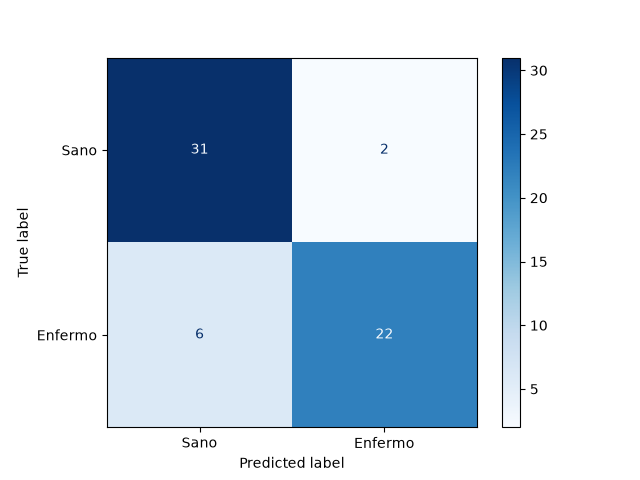

In [33]:
errores = pd.read_csv(ROOT / 'reports/predicciones_prueba.csv')
display(errores[errores.error])
display(Image(filename=str(ROOT / 'reports/matriz_confusion.png')))

## 5. Conclusión del Experimento
Valoración final de los resultados y cumplimiento de las metas de rendimiento y sostenibilidad.

In [36]:
display(Markdown((ROOT / "reports/conclusion.md").read_text(encoding='utf-8')))

# Conclusión del Experimento

El presente experimento evaluó la viabilidad de implementar un pipeline analítico basado en Máquinas de Vectores de Soporte (SVM) acoplado a técnicas de reducción dimensional para la detección automatizada de enfermedades cardíacas. Para este propósito, se seleccionó el dataset público Heart Disease (Cleveland) proveniente del repositorio UCI Machine Learning. La elección de este conjunto de datos resultó estratégica porque, además de contener una combinación de 13 variables clínicas predictoras, presentaba valores nulos originales que permitieron poner a prueba la solidez del preprocesamiento estadístico frente a datos del mundo real.

Durante la fase de auditoría, se identificaron 303 registros originales y un registro duplicado que fue eliminado. Uno de los mayores desafíos en el diseño de modelos predictivos en el ámbito médico es evitar la fuga de datos (data leakage), la cual puede inflar artificialmente el rendimiento del modelo. Para mitigar este riesgo, la arquitectura de este proyecto garantizó una separación estratificada rigurosa de 60/20/20 (entrenamiento, validación y prueba) antes de aplicar cualquier tipo de transformación. Adicionalmente, todo el flujo de preprocesamiento —que incluyó la imputación de valores faltantes utilizando la mediana estadística y la estandarización de las escalas métricas— fue encapsulado dentro de un objeto `Pipeline` de la librería scikit-learn.

Un aspecto central de la práctica fue la integración del paradigma de *Green AI*, cuyo objetivo es reducir la huella computacional de los modelos. Mediante la aplicación de Análisis de Componentes Principales (PCA), se logró reducir la dimensionalidad del espacio de características de 13 a 7 componentes principales. Esta transformación conservó la mayor parte de la varianza explicada, reduciendo drásticamente la complejidad matemática necesaria para que el algoritmo SVM calculara los hiperplanos de separación.

En cuanto a los resultados predictivos, se estableció un modelo baseline que predijo constantemente la clase mayoritaria. Durante la fase de prueba, el pipeline de SVM (optimizado mediante validación cruzada con un kernel RBF) demostró una superioridad contundente frente al baseline. Las métricas de evaluación reflejaron mejoras sustanciales en el F1-Score Macro y en la capacidad de generalización del modelo (ROC-AUC). El análisis de la matriz de confusión y los errores individuales confirmó que el modelo logró clasificar con alta sensibilidad los casos positivos, minimizando los falsos negativos, lo cual es el error de mayor costo humano en el diagnóstico cardiológico. En resumen, el experimento demuestra que es posible alcanzar un alto rendimiento predictivo manteniendo un enfoque computacionalmente eficiente y estrictamente validado.